# MAT 443 MIDTERM - Eric Baah

In [146]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.utils import resample

## Question 1

In [147]:
# Load the dataset
train = pd.read_csv("train_data.csv")  # Update with the correct file path
test = pd.read_csv("test_data.csv")  # Update with or handle them accordingly)

# Drop missing values if any 
train = train.dropna()
test = test.dropna()

# Creating Dummies from the qualitative predictors
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

In [148]:
# Training features (X) and target (y)
from ISLP.models import (ModelSpec as MS, summarize, poly)
X_train = MS(train.drop(columns=['cbv_avg'])).fit_transform(train)
y_train = train['cbv_avg']  # Target variable

# Testing features (X) and target (y)
X_test = MS(test.drop(columns=['cbv_avg'])).fit_transform(test)
y_test = test['cbv_avg']  # Target variable

Linear_Model1=sm.OLS(y_train, X_train).fit()
print(Linear_Model1.summary())

                            OLS Regression Results                            
Dep. Variable:                cbv_avg   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     3.282
Date:                Sat, 05 Oct 2024   Prob (F-statistic):           1.26e-13
Time:                        15:56:33   Log-Likelihood:                -2.9082
No. Observations:                 431   AIC:                             149.8
Df Residuals:                     359   BIC:                             442.6
Df Model:                          71                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          2.7196      0.288      9.

In [149]:
lm = LinearRegression()
Linear_Model1 = lm.fit(X_train, y_train)

# Predict on the test set
y_pred = Linear_Model1.predict(X_test)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Linear Model Test MSE: {test_mse}")

Linear Model Test MSE: 0.1325092505231665


In [150]:
# Using just Important Predictors 
# Training set of significant features (X) and target (y)
X_train_r = MS(['gbjw3', 'pbjw7', 'sef10', 'sd1', 'lj1', 'webhours', 'gender_Unknown']).fit_transform(train)
y_train = train['cbv_avg']  # Target variable

# Testing set of significant features (X) and target (y)
X_test_r = MS(['gbjw3', 'pbjw7', 'sef10', 'sd1', 'lj1', 'webhours', 'gender_Unknown']).fit_transform(test)
y_test = test['cbv_avg']  # Target variable

Linear_Model2=sm.OLS(y_train,X_train_r).fit()
print(Linear_Model2.summary())

                            OLS Regression Results                            
Dep. Variable:                cbv_avg   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     22.23
Date:                Sat, 05 Oct 2024   Prob (F-statistic):           1.30e-25
Time:                        15:56:33   Log-Likelihood:                -43.207
No. Observations:                 431   AIC:                             102.4
Df Residuals:                     423   BIC:                             134.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          2.1742      0.135     16.

In [151]:

Linear_Model2 = lm.fit(X_train_r, y_train)

# Predict on the test set
y_pred = Linear_Model1.predict(X_test_r)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Restricted Linear Model Test MSE: {test_mse}")

Restricted Linear Model Test MSE: 0.11925315470913446


Droping the nonsignificant predictors improves on the predictive performace of the model as we see the drop in the Test MSE from 0.13251 to 0.11925.The AIC and the BIC are also better for the smaller model.

## Question 2

In [152]:
# For Forward Selection

from ISLP.models import (Stepwise , sklearn_selected, sklearn_selection_path)
from statsmodels.api import OLS

X_full = MS(train.columns.drop('cbv_avg')).fit(train)


In [153]:
####negative AIC ####
def negAIC(estimator, X, Y):
    "Negative AIC"
    n, p = X.shape
    Yhat = estimator.predict(X)
    MSE = np.mean((Y - Yhat)**2)
    aic=n + n * np.log(MSE) + 2 * (p + 1)
    #print(f"AIC: {aic} for model with features: {X.columns.tolist()}")
    return -aic
####negative BIC####
def negBIC(estimator, X, Y):
    "Negative BIC"
    n, p = X.shape
    Yhat = estimator.predict(X)
    MSE = np.mean((Y - Yhat)**2)
    bic= n + n * np.log(MSE) + np.log(n) * (p + 1)
    #print(f"BIC: {bic} for model with features: {X.columns.tolist()}")
    return -bic


In [154]:
## Forward Selection
strategy_f = Stepwise.first_peak(X_full,direction='forward',max_terms=len(X_full.terms))

boston_aic = sklearn_selected(OLS,strategy_f,scoring=negAIC)
boston_aic.fit(train, y_train)
boston_aic.selected_state_

('gbjw2',
 'gbjw3',
 'gender_Male',
 'gender_Unknown',
 'lj1',
 'lj10',
 'lj2',
 'lj3',
 'lj7',
 'pbjw3',
 'pbjw5',
 'pbjw6',
 'pbjw7',
 'pt3',
 'sd1',
 'sef10',
 'sj3',
 'webhours')

In [155]:
X_train_f = MS(['gbjw2', 'gbjw3', 'gender_Male', 'gender_Unknown', 'lj1', 'lj10', 'lj2', 'lj3', 'lj7', 'pbjw3', 'pbjw5', 'pbjw6', 'pbjw7', 'pt3', 'sd1', 'sef10', 'sj3', 'webhours']).fit_transform(train)
y_train = train['cbv_avg']  # Target variable

# Testing set of significant features (X) and target (y)
X_test_f = MS(['gbjw2', 'gbjw3', 'gender_Male', 'gender_Unknown', 'lj1', 'lj10', 'lj2', 'lj3', 'lj7', 'pbjw3', 'pbjw5', 'pbjw6', 'pbjw7', 'pt3', 'sd1', 'sef10', 'sj3', 'webhours']).fit_transform(test)
y_test = test['cbv_avg']  # Target variable

Linear_Model2=sm.OLS(y_train,X_train_f).fit()
print(Linear_Model2.summary())

Linear_Model2 = lm.fit(X_train_f, y_train)

# Predict on the test set
y_pred = Linear_Model1.predict(X_test_f)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Forward Selection Test MSE: {test_mse}")



                            OLS Regression Results                            
Dep. Variable:                cbv_avg   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     12.06
Date:                Sat, 05 Oct 2024   Prob (F-statistic):           2.75e-28
Time:                        15:56:50   Log-Likelihood:                -19.478
No. Observations:                 431   AIC:                             76.96
Df Residuals:                     412   BIC:                             154.2
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          2.2970      0.171     13.

In [156]:
## Backward Selection
strategy_b = Stepwise.first_peak(X_full,direction='backward',initial_terms=X_full.terms,max_terms=len(X_full.terms))

boston_aic = sklearn_selected(OLS,strategy_b,scoring=negAIC)
boston_aic.fit(train, y_train)
boston_aic.selected_state_

('emp2',
 'gbjw2',
 'gbjw3',
 'gender_Male',
 'gender_Unknown',
 'lj1',
 'lj10',
 'lj2',
 'lj3',
 'lj7',
 'pbjw3',
 'pbjw5',
 'pbjw6',
 'pbjw7',
 'persta5',
 'sd1',
 'sef10',
 'sef7',
 'sj3',
 'webhours')

In [157]:
X_train_b = MS(['emp2', 'gbjw2', 'gbjw3', 'gender_Male', 'gender_Unknown', 'lj1', 'lj10', 'lj2', 'lj3', 'lj7', 'pbjw3', 'pbjw5', 'pbjw6', 'pbjw7', 'persta5', 'sd1', 'sef10', 'sef7', 'sj3', 'webhours']).fit_transform(train)
y_train = train['cbv_avg']  # Target variable

# Testing set of significant features (X) and target (y)
X_test_b = MS(['emp2', 'gbjw2', 'gbjw3', 'gender_Male', 'gender_Unknown', 'lj1', 'lj10', 'lj2', 'lj3', 'lj7', 'pbjw3', 'pbjw5', 'pbjw6', 'pbjw7', 'persta5', 'sd1', 'sef10', 'sef7', 'sj3', 'webhours']).fit_transform(test)
y_test = test['cbv_avg']  # Target variable

Linear_Model2=sm.OLS(y_train,X_train_b).fit()
print(Linear_Model2.summary())

Linear_Model2 = lm.fit(X_train_b, y_train)

# Predict on the test set
y_pred = Linear_Model1.predict(X_test_b)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Backward Selection Test MSE: {test_mse}")

                            OLS Regression Results                            
Dep. Variable:                cbv_avg   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     11.12
Date:                Sat, 05 Oct 2024   Prob (F-statistic):           5.21e-28
Time:                        15:59:23   Log-Likelihood:                -17.348
No. Observations:                 431   AIC:                             76.70
Df Residuals:                     410   BIC:                             162.1
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          2.4553      0.186     13.

The forward and backward selections yield slightly different models. Forward selection has a total of 18 predictors whiles backward selection has a total of 20 predictors. This is because with forward selection with AIC as a selection criterion, it starts from the null model and gradually add the most important predictors and tends to favor a more parsimonuos model compared to the backward selection that starts with the model with all predictors (saturated model) and gradually drop the least important feature at each step. For this dataset, the backward selection (Test MSE = 0.1150686) appears to have a slightly better performance compared to forward selection (Test MSE = 0.117965).

## Question 3

In [158]:
# Sacled Training features (X) and target (y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
y_train = train['cbv_avg']  # Target variable

# Sacled Testing features (X) and target (y)
X_test_scaled = scaler.fit_transform(X_test)
y_test = test['cbv_avg']  # Target variable

In [159]:
# Apply Ridge with cross-validation to find the optimal alpha (lambda)
ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5).fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = ridge_cv.predict(X_test_scaled)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse}")

# Report non-zero coefficients
non_zero_coef = pd.Series(ridge_cv.coef_, index=X_train.columns)
print("Non-zero coefficients:")
print(non_zero_coef[non_zero_coef != 0])

# Optimal alpha (lambda)
print(f"Optimal lambda: {ridge_cv.alpha_}")

Test MSE: 0.1241190380689227
Non-zero coefficients:
persta1           0.005858
persta2          -0.001318
persta3           0.007722
persta4           0.031435
persta5          -0.021803
                    ...   
sj6              -0.013010
age              -0.005481
webhours          0.031867
gender_Male       0.025774
gender_Unknown    0.044201
Length: 71, dtype: float64
Optimal lambda: 10.0


In [160]:
# Apply Lasso with cross-validation to find the optimal alpha (lambda)
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = lasso_cv.predict(X_test_scaled)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse}")

# Report non-zero coefficients
non_zero_coef = pd.Series(lasso_cv.coef_, index=X_train.columns)
print("Non-zero coefficients:")
print(non_zero_coef[non_zero_coef != 0])

# Optimal alpha (lambda)
print(f"Optimal lambda: {lasso_cv.alpha_}")
len(non_zero_coef[non_zero_coef != 0] != 0)

Test MSE: 0.10472875075669534
Non-zero coefficients:
pt3              -0.006470
emp2             -0.002213
gbjw3             0.006283
pbjw3            -0.002102
pbjw6             0.000002
pbjw7            -0.049730
sef10             0.012515
sd1              -0.039709
sd7              -0.001823
lj1              -0.033209
lj2              -0.004844
lj3              -0.005499
lj7              -0.016227
lj10              0.014403
sj3              -0.034440
webhours          0.023853
gender_Male       0.019720
gender_Unknown    0.035215
dtype: float64
Optimal lambda: 0.016809891833200984


18

The Lasso model dropped 51 predictors out of the 71. The difference between Lasso and Ridge regression is that with Lasso, it uses the L-1 norm penalty term and is able to shrink coefficients to zero, thereby performing variable selection while Ridge cannot shrink parameters to exactly zero. Based on test MSEs, the Lasso model performs better compared to the Ridge model.

## Question 4

In [161]:
## PCR Regression

### Cross-validation to select the optimal number of components for PCR
mse_values = []  # Store the MSE for each number of components
for n_components in range(1, X_train.shape[1]+1):
    # Perform PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)

    # Fit Linear Regression model on the principal components
    pcr_model = LinearRegression()

    # Perform 5-fold cross-validation and calculate the MSE
    mse = -np.mean(cross_val_score(pcr_model, X_train_pca, y_train, scoring='neg_mean_squared_error', cv=5))
    mse_values.append(mse)

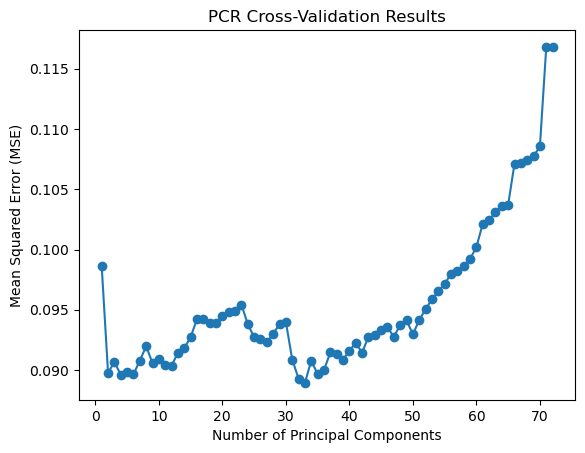

In [162]:
# Plot the results of PCR
import matplotlib.pyplot as plt
plt.plot(range(1, X_train.shape[1]+1), mse_values, marker='o')

plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('PCR Cross-Validation Results')
plt.show()

In [163]:
# Find the optimal number of principal components (minimizing MSE)
best_n_components_pcr = np.argmin(mse_values) + 1
print(f"Optimal number of principal components for PCR: {best_n_components_pcr}")


Optimal number of principal components for PCR: 33


In [164]:
### Refit PCR model using the optimal number of components on the full training set
# Apply PCA with the optimal number of components
pca = PCA(n_components=best_n_components_pcr)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [165]:
# Fit the PCR model (Linear Regression on the principal components)
pcr_model = LinearRegression()
pcr_model.fit(X_train_pca, y_train)

# Make predictions on the test set
pcr_pred = pcr_model.predict(X_test_pca)
# Calculate the MSE on the test set
pcr_mse = mean_squared_error(y_test, pcr_pred)
print(f"PCR MSE on test set with {best_n_components_pcr} components: {pcr_mse}")

PCR MSE on test set with 33 components: 0.10572500647803335


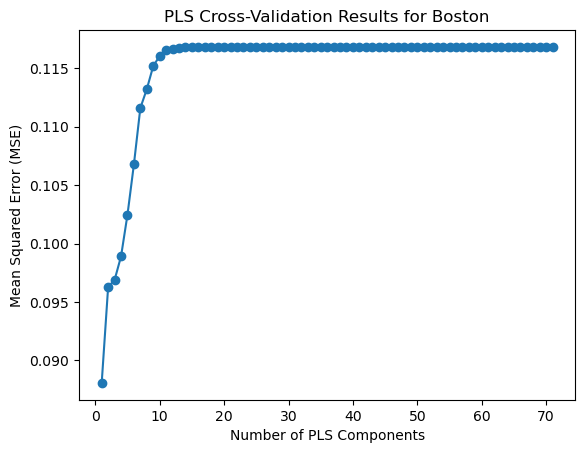

In [166]:
## PLS Regresssion

### Cross-validation to select the optimal number of components for PLS
mse_values = []  # Store the MSE for each number of components

# Perform cross-validation for different numbers of components
for n_components in range(1, X_train.shape[1]):
    # Initialize PLS with n_components
    pls_model = PLSRegression(n_components=n_components)

    # Perform 5-fold cross-validation and calculate the MSE
    mse = -np.mean(cross_val_score(pls_model, X_train, y_train, scoring='neg_mean_squared_error', cv=5))
    mse_values.append(mse)

# Ensure mse_values contains the same number of elements as the number of components tested
n_components_tested = len(mse_values)

# Plot the cross-validation results to visualize the best number of components
plt.plot(range(1, n_components_tested + 1), mse_values, marker='o')
plt.xlabel('Number of PLS Components')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('PLS Cross-Validation Results for Boston')
plt.show()

In [167]:
# Find the optimal number of components (minimizing MSE)
best_n_components_pls = np.argmin(mse_values) + 1
print(f"Optimal number of PLS components for Boston: {best_n_components_pls}")


Optimal number of PLS components for Boston: 1


In [168]:
### Refit PLS model using the optimal number of components on the full training set
# Fit the PLS model with the optimal number of components
pls_best_model = PLSRegression(n_components=best_n_components_pls)
pls_best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pls_best_model.predict(X_test)

# Calculate the MSE on the test set
pls_mse = mean_squared_error(y_test, y_pred)
print(f"PLS MSE on test set with {best_n_components_pls} components: {pls_mse}")


PLS MSE on test set with 1 components: 0.10029702941171607


PCR ignores the response variable while identifying the principal components. It focuses solely on maximizing the variance in the predictors and then uses the selected components in the regression, regardless of how well they predict the response. On the other hand, PLS attempts to find components that maximize the covariance between the predictors and the response variable, making it more directly focused on improving prediction accuracy.

## Question 5

Overall, the PLS models gives the best performace on this dataset among all the models. It has the least Test MSE (0.100297) among all the models. This might be because of a possible collinerity in the data which makes the PLS outperform the other models. The PLS did not only focus on maximizing the covariance in the features but also the response which imporved its prediction accuracy.

## Question 6


In [169]:
# Function to perform Random Lasso using bootstrap and cross-validation for lambda
def random_lasso_cv(X_train_scaled, y_train, n_bootstraps=100, subset_size=0.7, cv=5):
    coef_matrix = []
    alpha_matrix = []
    
    for i in range(n_bootstraps):
        # Bootstrap sampling
        X_sample, y_sample = resample(X_train_scaled, y_train, n_samples=int(subset_size * X_train.shape[0]), random_state=i)
        
        # Apply LassoCV to the bootstrap sample
        lasso_cv = LassoCV(cv=cv, random_state=i).fit(X_sample, y_sample)
        
        # Collect the coefficients and the optimal alpha (lambda)
        coef_matrix.append(lasso_cv.coef_)
        alpha_matrix.append(lasso_cv.alpha_)
    
    # Average the coefficients and the lambda values across all bootstraps
    avg_coefs = np.mean(coef_matrix, axis=0)
    avg_alpha = np.mean(alpha_matrix)
    
    return avg_coefs, avg_alpha

# Perform Random Lasso with cross-validation
n_bootstraps = 100
subset_size = 0.7

avg_coefs, avg_alpha = random_lasso_cv(X_train_scaled, y_train, n_bootstraps=n_bootstraps, subset_size=subset_size)

# Report non-zero coefficients
non_zero_coefs = pd.Series(avg_coefs, index=X_train.columns)
non_zero_coefs = non_zero_coefs[non_zero_coefs != 0]

print("Non-zero coefficients from Random Lasso:")
print(non_zero_coefs)

# Report the average lambda (alpha) used across the bootstraps
print(f"Average lambda (alpha) across bootstraps: {avg_alpha}")

# Now, evaluate the performance on the test set using Lasso with the average alpha
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=avg_alpha)
lasso.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = lasso.predict(X_test_scaled)

# Calculate the test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse}")

Non-zero coefficients from Random Lasso:
persta1          -0.000189
persta2          -0.000745
persta3           0.001121
persta4           0.003261
persta5          -0.003283
                    ...   
sj6              -0.003867
age              -0.003500
webhours          0.021058
gender_Male       0.016682
gender_Unknown    0.034103
Length: 71, dtype: float64
Average lambda (alpha) across bootstraps: 0.01825206661895366
Test MSE: 0.1046434579225748


Even though the Random Lasso outperforms the traditional Lasso on this dataset, its test MSE is slightly higher than that of PLS. Despite this it is still an improvement on the early models.